# Notebook 2: Offline-Novelty-Detection auf TCLab-Simulationsdaten

## Ziel dieses Notebooks

In diesem Notebook werden versionierte Simulationsdaten aus Notebook 1 geladen, zusammengeführt und für Verfahren der Novelty Detection vorbereitet.

Das Notebook behandelt:

- Laden einer oder mehrerer Datensatzversionen
- Run-weisen Split als Best Practice gegen Leakage
- Fensterbildung als Basiseinheit für die Modellierung
- getrennte Vorverarbeitung für klassische Verfahren und Deep Learning
- Vergleich von **PCA**, **Isolation Forest**, **One-Class SVM** und einem **shallow Autoencoder**
- kontrollierten Simulations-Test mit injizierten Anomalien
- quantitative Auswertung zentraler Fault-Detection-Kennzahlen

<div style="border:1px solid #999; padding:10px; border-radius:6px; background:#f8f8f8;">
<b>Lernziel:</b> Die Studierenden sollen versionierte Simulationsdaten strukturiert laden, auf Run-Ebene ohne Leakage aufteilen, Fenster als Modellierungseinheit verstehen und erste Verfahren der Novelty Detection auf kontrollierten Simulationsfehlern vergleichen.
</div>


## Einordnung

Dieses Notebook ist der zweite Teil der Reihe:

1. Datengenerierung und Aufbau eines NOC-Datensatzes
2. Offline-Novelty-Detection auf Simulationsdaten
3. Transfer auf reale Hardware und Nachtraining

In Notebook 2 werden nur **Modelldaten** genutzt. Die Verbesserung der Erkennung auf Simulationsdaten steht im Vordergrund.


In [3]:
from __future__ import annotations

import json
import math
from pathlib import Path
from typing import Any, Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import IsolationForest
from sklearn.svm import OneClassSVM

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

plt.rcParams["figure.figsize"] = (12, 4)
plt.rcParams["axes.grid"] = True

GLOBAL_RANDOM_SEED = 42
np.random.seed(GLOBAL_RANDOM_SEED)
torch.manual_seed(GLOBAL_RANDOM_SEED)

print("torch:", torch.__version__)


torch: 2.6.0+cpu


## Konfiguration

In [5]:
CONFIG = {
    "base_data_dir": "data",                        # Hauptdatenverzeichnis
    "dataset_versions": ["v1"],                    # Verwendete Datensatzversionen
    "source_filter": "model",                      # Nur simulierte Daten verwenden

    "feature_cols": ["T1", "T2"],                  # Standardmerkmale für die Erkennung
    # "feature_cols": ["Q1", "Q2", "T1", "T2"],    # Optionale erweiterte Merkmalswahl

    "train_ratio": 0.60,                           # Anteil Training
    "val_ratio": 0.25,                             # Anteil Validierung
    "test_ratio": 0.15,                            # Anteil Test
    "split_random_state": 42,                      # Reproduzierbarer Zufallszustand für den Split
    "stratify_mode": "profile_family_then_version",

    "window_length_s": 15,                         # Fensterlänge in Sekunden
    "window_step_s": 2,                            # Schrittweite zwischen zwei Fenstern in Sekunden

    "pca_n_components": 0.90,                      # Zielanteil erklärter Varianz der PCA

    "if_n_estimators": 500,                        # Anzahl Bäume des Isolation Forest
    "if_max_samples": "auto",
    "if_random_state": 42,

    "ocsvm_kernel": "rbf",
    "ocsvm_nu": 0.02,
    "ocsvm_gamma": "scale",

    "ae_hidden_dim": 32,                           # Verdeckte Schicht des Autoencoders
    "ae_bottleneck_dim": 8,                        # Bottleneck-Dimension des Autoencoders
    "ae_dropout": 0.0,
    "ae_batch_size": 64,
    "ae_epochs": 50,                               # Anzahl Trainings-Epochen
    "ae_learning_rate": 1e-3,
    "ae_weight_decay": 1e-5,

    "target_far": 0.01,                           # Ziel-False-Alarm-Rate für die Schwellenbildung (bspw 0,1 %)

    "demo_profile_family": None,
    "demo_run_id": None,
    "demo_point_start_s": 120,
    "demo_point_duration_s": 5,
    "demo_point_amplitude_degC": 4.0,

    "demo_shift_start_s": 260,
    "demo_shift_end_s": 360,
    "demo_shift_amplitude_degC": 2.5,

    "demo_osc_start_s": 430,
    "demo_osc_end_s": 520,
    "demo_osc_amplitude_degC": 1.5,
    "demo_osc_period_s": 12,

    "alarm_merge_gap_windows": 1,
    "persistency_horizon_windows": 3,
}
CONFIG


{'base_data_dir': 'data',
 'dataset_versions': ['v1'],
 'source_filter': 'model',
 'feature_cols': ['T1', 'T2'],
 'train_ratio': 0.6,
 'val_ratio': 0.25,
 'test_ratio': 0.15,
 'split_random_state': 42,
 'stratify_mode': 'profile_family_then_version',
 'window_length_s': 15,
 'window_step_s': 2,
 'pca_n_components': 0.9,
 'if_n_estimators': 500,
 'if_max_samples': 'auto',
 'if_random_state': 42,
 'ocsvm_kernel': 'rbf',
 'ocsvm_nu': 0.02,
 'ocsvm_gamma': 'scale',
 'ae_hidden_dim': 32,
 'ae_bottleneck_dim': 8,
 'ae_dropout': 0.0,
 'ae_batch_size': 64,
 'ae_epochs': 50,
 'ae_learning_rate': 0.001,
 'ae_weight_decay': 1e-05,
 'target_far': 0.01,
 'demo_profile_family': None,
 'demo_run_id': None,
 'demo_point_start_s': 120,
 'demo_point_duration_s': 5,
 'demo_point_amplitude_degC': 4.0,
 'demo_shift_start_s': 260,
 'demo_shift_end_s': 360,
 'demo_shift_amplitude_degC': 2.5,
 'demo_osc_start_s': 430,
 'demo_osc_end_s': 520,
 'demo_osc_amplitude_degC': 1.5,
 'demo_osc_period_s': 12,
 'alarm_m

## Daten laden

Es können eine oder mehrere Datensatzversionen gemeinsam geladen werden. Dabei wird die Herkunft jeder Version explizit mitgeführt.

In [7]:

def read_partitioned_or_flat_dataframe(parquet_target: Path, csv_target: Path) -> pd.DataFrame:
    """
    Lädt gezielt:
    - einzelne Parquet-Datei
    - Parquet-Ordner mit *.parquet
    - einzelne CSV-Datei
    - CSV-Ordner mit *.csv

    Wichtig:
    Wenn Parquet-Dateien vorhanden sind, werden nur diese gelesen.
    """
    # 1) Parquet-Datei
    if parquet_target.exists() and parquet_target.is_file() and parquet_target.suffix.lower() == ".parquet":
        return pd.read_parquet(parquet_target)

    # 2) Parquet-Ordner
    if parquet_target.exists() and parquet_target.is_dir():
        parquet_files = sorted(parquet_target.glob("*.parquet"))
        if len(parquet_files) > 0:
            return pd.concat([pd.read_parquet(f) for f in parquet_files], ignore_index=True)

    # 3) einzelne CSV-Datei
    if csv_target.exists() and csv_target.is_file() and csv_target.suffix.lower() == ".csv":
        return pd.read_csv(csv_target)

    # 4) CSV-Ordner
    if csv_target.exists() and csv_target.is_dir():
        csv_files = sorted(csv_target.glob("*.csv"))
        if len(csv_files) > 0:
            return pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

    raise FileNotFoundError(
        f"Weder passende Parquet- noch CSV-Dateien gefunden:\n- {parquet_target}\n- {csv_target}"
    )


def load_notebook1_version(base_dir: str, version: str):
    """
    Lädt genau die in Notebook 1 erzeugte Struktur:
    data/<version>/timeseries/source=model/
    data/<version>/run_metadata/source=model/
    data/<version>/config/notebook_config.json
    """
    version_dir = Path(base_dir) / version

    # Zeitreihendaten: partitioniert nach source=model
    ts_parquet = version_dir / "timeseries" / "source=model"
    ts_csv = version_dir / "timeseries" / "source=model"

    # Run-Metadaten: ebenfalls partitioniert nach source=model
    meta_parquet = version_dir / "run_metadata" / "source=model"
    meta_csv = version_dir / "run_metadata" / "source=model"

    config_json = version_dir / "config" / "notebook_config.json"

    ts_df = read_partitioned_or_flat_dataframe(ts_parquet, ts_csv)
    meta_df = read_partitioned_or_flat_dataframe(meta_parquet, meta_csv)

    if config_json.exists():
        with open(config_json, "r", encoding="utf-8") as f:
            exported_config = json.load(f)
    else:
        exported_config = {}

    ts_df = ts_df.copy()
    meta_df = meta_df.copy()

    ts_df["dataset_version"] = version
    meta_df["dataset_version"] = version

    return ts_df, meta_df, exported_config


def load_multiple_versions(base_dir: str, versions: list[str]):
    """
    Lädt eine oder mehrere Versionen und führt sie zusammen.
    """
    all_ts = []
    all_meta = []
    all_cfg = {}

    for version in versions:
        ts_df, meta_df, cfg = load_notebook1_version(base_dir, version)
        all_ts.append(ts_df)
        all_meta.append(meta_df)
        all_cfg[version] = cfg

    timeseries_df = pd.concat(all_ts, ignore_index=True)
    metadata_df = pd.concat(all_meta, ignore_index=True)

    return timeseries_df, metadata_df, all_cfg

In [8]:
timeseries_df, metadata_df, exported_configs = load_multiple_versions(
    base_dir=CONFIG["base_data_dir"],
    versions=CONFIG["dataset_versions"],
)

timeseries_df = timeseries_df.copy()
metadata_df = metadata_df.copy()

timeseries_df["global_run_id"] = (
    timeseries_df["dataset_version"].astype(str) + "__" + timeseries_df["run_id"].astype(str)
)
metadata_df["global_run_id"] = (
    metadata_df["dataset_version"].astype(str) + "__" + metadata_df["run_id"].astype(str)
)

if CONFIG["source_filter"] is not None:
    timeseries_df = timeseries_df[timeseries_df["source"] == CONFIG["source_filter"]].copy()
    metadata_df = metadata_df[metadata_df["source"] == CONFIG["source_filter"]].copy()

print("Timeseries Shape:", timeseries_df.shape)
print("Metadata Shape:", metadata_df.shape)

timeseries_df.head(), metadata_df.head()

Timeseries Shape: (14382, 17)
Metadata Shape: (24, 27)


(     run_id source profile_family  profile_variant  sample_time_s  t_sec   Q1  \
 0  run_0001  model    q2_dominant  q2_dominant_v01            1.0   0.00  0.0   
 1  run_0001  model    q2_dominant  q2_dominant_v01            1.0   1.46  0.0   
 2  run_0001  model    q2_dominant  q2_dominant_v01            1.0   2.05  0.0   
 3  run_0001  model    q2_dominant  q2_dominant_v01            1.0   3.03  0.0   
 4  run_0001  model    q2_dominant  q2_dominant_v01            1.0   4.05  0.0   
 
     Q2       T1       T2  ambient_ref    phase       split  run_ok notes  \
 0  0.0  20.9495  20.9495      20.9495  initial  unassigned    True         
 1  0.0  20.9495  20.9495      20.9495  initial  unassigned    True         
 2  0.0  20.9495  20.9495      20.9495  initial  unassigned    True         
 3  0.0  20.9495  20.9495      20.9495  initial  unassigned    True         
 4  0.0  20.9495  20.6272      20.9495  initial  unassigned    True         
 
   dataset_version global_run_id  
 0     

## Qualitätsprüfung und Kompatibilität

Vor dem Split wird geprüft, ob die geladenen Datensatzversionen grundsätzlich zusammenpassen.

In [10]:
def summarize_loaded_data(timeseries_df: pd.DataFrame, metadata_df: pd.DataFrame) -> None:
    print("Geladene Versionen:", sorted(metadata_df["dataset_version"].unique().tolist()))
    print("Quellen:", sorted(metadata_df["source"].unique().tolist()))
    print("Anzahl Runs:", metadata_df["global_run_id"].nunique())
    print("Anzahl Zeilen:", len(timeseries_df))
    print("Profilfamilien:", sorted(metadata_df["profile_family"].dropna().unique().tolist()))
    print("Sample Times:", sorted(metadata_df["sample_time_s"].dropna().unique().tolist()))
    print("Run-Dauern:", sorted(metadata_df["duration_s"].dropna().unique().tolist()))

    duplicate_runs = metadata_df["global_run_id"].duplicated().sum()
    print("Doppelte global_run_id in Metadaten:", int(duplicate_runs))

    missing_ts = timeseries_df.isna().sum().sum()
    missing_meta = metadata_df.isna().sum().sum()
    print("Fehlende Werte Zeitreihen:", int(missing_ts))
    print("Fehlende Werte Metadaten:", int(missing_meta))


summarize_loaded_data(timeseries_df, metadata_df)

Geladene Versionen: ['v1']
Quellen: ['model']
Anzahl Runs: 24
Anzahl Zeilen: 14382
Profilfamilien: ['coordinated', 'q1_dominant', 'q2_dominant', 'staggered_steps']
Sample Times: [1.0]
Run-Dauern: [600]
Doppelte global_run_id in Metadaten: 0
Fehlende Werte Zeitreihen: 0
Fehlende Werte Metadaten: 0


In [11]:
metadata_df.groupby(["dataset_version", "profile_family"]).size().rename("n_runs")

dataset_version  profile_family 
v1               coordinated        7
                 q1_dominant        4
                 q2_dominant        9
                 staggered_steps    4
Name: n_runs, dtype: int64

In [12]:
metadata_df[["dataset_version", "global_run_id", "profile_family", "duration_s", "sample_time_s"]].head()

,dataset_version,global_run_id,profile_family,duration_s,sample_time_s
0,v1,v1__run_0001,q2_dominant,600,1.0
1,v1,v1__run_0002,staggered_steps,600,1.0
2,v1,v1__run_0003,q1_dominant,600,1.0
3,v1,v1__run_0004,coordinated,600,1.0
4,v1,v1__run_0005,q2_dominant,600,1.0


## Run-weiser Split

<div style="border:1px solid #999; padding:10px; border-radius:6px; background:#f8f8f8;">
<b>Best Practice:</b> Der Split erfolgt auf <b>Run-Ebene</b> vor der Fensterbildung. Dadurch landen keine stark ähnlichen Abschnitte desselben Runs gleichzeitig in Training und Validierung/Test.
</div>

In [14]:
def build_stratify_label(meta: pd.DataFrame, mode: str = "profile_family_then_version") -> pd.Series:
    profile = meta["profile_family"].astype(str)

    if mode == "profile_family_only":
        return profile

    if mode == "profile_family_then_version":
        combined = meta["profile_family"].astype(str) + "__" + meta["dataset_version"].astype(str)
        counts = combined.value_counts()
        rare = set(counts[counts < 3].index.tolist())
        combined = combined.where(~combined.isin(rare), profile)
        return combined

    raise ValueError(f"Unbekannter stratify_mode: {mode}")


def split_runs_runwise(
    metadata_df: pd.DataFrame,
    train_ratio: float,
    val_ratio: float,
    test_ratio: float,
    random_state: int,
    stratify_mode: str,
) -> pd.DataFrame:
    if not math.isclose(train_ratio + val_ratio + test_ratio, 1.0, rel_tol=1e-9):
        raise ValueError("train_ratio + val_ratio + test_ratio muss 1.0 ergeben.")

    run_meta = metadata_df[
        ["global_run_id", "dataset_version", "profile_family"]
    ].drop_duplicates().reset_index(drop=True)

    stratify_labels = build_stratify_label(run_meta, mode=stratify_mode)

    train_val_runs, test_runs = train_test_split(
        run_meta,
        test_size=test_ratio,
        random_state=random_state,
        stratify=stratify_labels,
    )

    train_val_stratify = build_stratify_label(train_val_runs, mode=stratify_mode)
    relative_val_ratio = val_ratio / (train_ratio + val_ratio)

    train_runs, val_runs = train_test_split(
        train_val_runs,
        test_size=relative_val_ratio,
        random_state=random_state,
        stratify=train_val_stratify,
    )

    train_runs = train_runs.assign(split="train")
    val_runs = val_runs.assign(split="val")
    test_runs = test_runs.assign(split="test")

    split_df = pd.concat([train_runs, val_runs, test_runs], ignore_index=True)
    return split_df


run_split_df = split_runs_runwise(
    metadata_df=metadata_df,
    train_ratio=CONFIG["train_ratio"],
    val_ratio=CONFIG["val_ratio"],
    test_ratio=CONFIG["test_ratio"],
    random_state=CONFIG["split_random_state"],
    stratify_mode=CONFIG["stratify_mode"],
)

run_split_df.head()

,global_run_id,dataset_version,profile_family,split
0,v1__run_0009,v1,q2_dominant,train
1,v1__run_0014,v1,coordinated,train
2,v1__run_0019,v1,q2_dominant,train
3,v1__run_0016,v1,q2_dominant,train
4,v1__run_0010,v1,q2_dominant,train


In [15]:
timeseries_df = timeseries_df.merge(
    run_split_df[["global_run_id", "split"]],
    on="global_run_id",
    how="left",
)

metadata_df = metadata_df.drop(columns=["split"], errors="ignore").merge(
    run_split_df[["global_run_id", "split"]],
    on="global_run_id",
    how="left",
)

metadata_df.groupby("split").size().rename("n_runs")

split
test      4
train    14
val       6
Name: n_runs, dtype: int64

In [16]:
metadata_df.groupby(["split", "profile_family"]).size().rename("n_runs")

split  profile_family 
test   coordinated        1
       q1_dominant        1
       q2_dominant        1
       staggered_steps    1
train  coordinated        4
       q1_dominant        2
       q2_dominant        6
       staggered_steps    2
val    coordinated        2
       q1_dominant        1
       q2_dominant        2
       staggered_steps    1
Name: n_runs, dtype: int64

## Fensterbildung

<div style="border:1px solid #999; padding:10px; border-radius:6px; background:#f8f8f8;">
<b>Definition:</b> Ein Fenster ist ein zusammenhängender Zeitabschnitt eines Runs. Es bildet die Basiseinheit für die spätere Modellierung und dient als Trainingseinheit für Verfahren des maschinellen Lernens und des Deep Learnings.
</div>

In [18]:
def get_window_params(sample_time_s: float, window_length_s: int, window_step_s: int) -> Tuple[int, int]:
    window_len = int(round(window_length_s / sample_time_s))
    window_step = int(round(window_step_s / sample_time_s))
    return window_len, window_step


def build_windows_for_one_run(
    run_df: pd.DataFrame,
    feature_cols: List[str],
    window_length_s: int,
    window_step_s: int,
) -> Tuple[np.ndarray, pd.DataFrame]:
    run_df = run_df.sort_values("t_sec").reset_index(drop=True)
    sample_time_s = float(run_df["sample_time_s"].iloc[0])
    window_len, window_step = get_window_params(sample_time_s, window_length_s, window_step_s)

    values = run_df[feature_cols].to_numpy(dtype=float)
    n = len(values)

    windows = []
    rows = []

    for start in range(0, n - window_len + 1, window_step):
        end = start + window_len
        x_win = values[start:end]

        windows.append(x_win)
        rows.append({
            "global_run_id": run_df["global_run_id"].iloc[0],
            "dataset_version": run_df["dataset_version"].iloc[0],
            "run_id": run_df["run_id"].iloc[0],
            "profile_family": run_df["profile_family"].iloc[0],
            "split": run_df["split"].iloc[0],
            "sample_time_s": sample_time_s,
            "window_start_idx": start,
            "window_end_idx": end - 1,
            "window_start_s": float(run_df["t_sec"].iloc[start]),
            "window_end_s": float(run_df["t_sec"].iloc[end - 1]),
        })

    return np.asarray(windows, dtype=float), pd.DataFrame(rows)

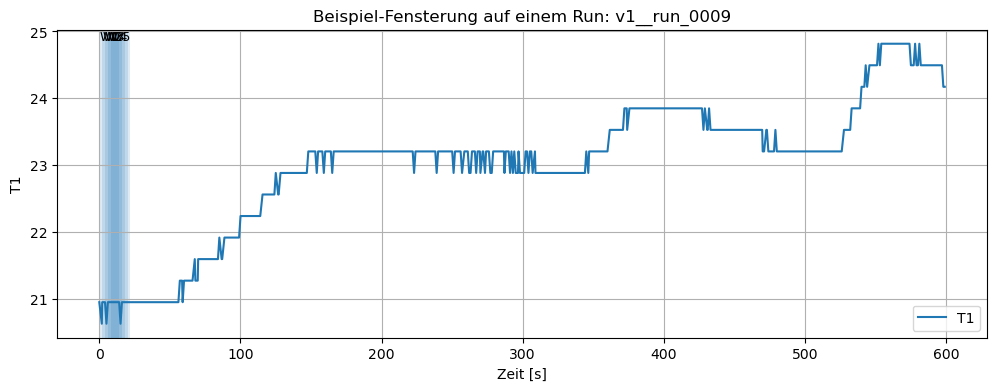

In [19]:
def plot_windowing_example(
    timeseries_df: pd.DataFrame,
    metadata_df: pd.DataFrame,
    feature_col: str = "T1",
    n_windows_to_show: int = 5,
) -> None:
    example_run_id = (
        metadata_df.loc[metadata_df["split"] == "train", "global_run_id"].iloc[0]
    )
    run_df = timeseries_df[timeseries_df["global_run_id"] == example_run_id].sort_values("t_sec").reset_index(drop=True)

    sample_time_s = float(run_df["sample_time_s"].iloc[0])
    window_len, window_step = get_window_params(
        sample_time_s,
        CONFIG["window_length_s"],
        CONFIG["window_step_s"],
    )

    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(run_df["t_sec"], run_df[feature_col], label=feature_col)

    for i, start in enumerate(range(0, len(run_df) - window_len + 1, window_step)):
        if i >= n_windows_to_show:
            break
        end = start + window_len
        ax.axvspan(run_df["t_sec"].iloc[start], run_df["t_sec"].iloc[end - 1], alpha=0.15)
        ax.text(
            run_df["t_sec"].iloc[start],
            run_df[feature_col].max(),
            f"W{i+1}",
            fontsize=9,
            va="bottom"
        )

    ax.set_title(f"Beispiel-Fensterung auf einem Run: {example_run_id}")
    ax.set_xlabel("Zeit [s]")
    ax.set_ylabel(feature_col)
    ax.legend()
    plt.show()


plot_windowing_example(timeseries_df, metadata_df)


In [20]:
# Diese zusätzliche Split-Zelle bleibt bewusst erhalten,
# damit die Split-Information vor der Fensterbildung sicher in den Zeitreihendaten vorliegt.

timeseries_df = timeseries_df.merge(
    run_split_df[["global_run_id", "split"]],
    on="global_run_id",
    how="left",
)

metadata_df = metadata_df.drop(columns=["split"], errors="ignore").merge(
    run_split_df[["global_run_id", "split"]],
    on="global_run_id",
    how="left",
)

display(metadata_df.groupby("split").size().rename("n_runs"))
display(metadata_df.groupby(["split", "profile_family"]).size().rename("n_runs"))


split
test      4
train    14
val       6
Name: n_runs, dtype: int64

split  profile_family 
test   coordinated        1
       q1_dominant        1
       q2_dominant        1
       staggered_steps    1
train  coordinated        4
       q1_dominant        2
       q2_dominant        6
       staggered_steps    2
val    coordinated        2
       q1_dominant        1
       q2_dominant        2
       staggered_steps    1
Name: n_runs, dtype: int64

In [21]:
def build_all_windows(
    timeseries_df: pd.DataFrame,
    feature_cols: List[str],
    window_length_s: int,
    window_step_s: int,
) -> Tuple[np.ndarray, pd.DataFrame]:
    all_windows = []
    all_meta = []

    for global_run_id, run_df in timeseries_df.groupby("global_run_id"):
        x, m = build_windows_for_one_run(
            run_df=run_df,
            feature_cols=feature_cols,
            window_length_s=window_length_s,
            window_step_s=window_step_s,
        )
        all_windows.append(x)
        all_meta.append(m)

    X = np.concatenate(all_windows, axis=0)
    meta = pd.concat(all_meta, ignore_index=True)
    return X, meta


X_all, window_meta_all = build_all_windows(
    timeseries_df=timeseries_df,
    feature_cols=CONFIG["feature_cols"],
    window_length_s=CONFIG["window_length_s"],
    window_step_s=CONFIG["window_step_s"],
)

X_all.shape, window_meta_all.shape

((7028, 15, 2), (7028, 10))

In [22]:
def split_window_arrays(
    X_all: np.ndarray,
    window_meta_all: pd.DataFrame,
) -> Dict[str, Tuple[np.ndarray, pd.DataFrame]]:
    result = {}
    for split_name in ["train", "val", "test"]:
        idx = window_meta_all["split"] == split_name
        result[split_name] = (X_all[idx.to_numpy()], window_meta_all[idx].reset_index(drop=True))
    return result


window_splits = split_window_arrays(X_all, window_meta_all)

for split_name, (X_split, meta_split) in window_splits.items():
    print(split_name, X_split.shape, meta_split.shape)

train (4099, 15, 2) (4099, 10)
val (1758, 15, 2) (1758, 10)
test (1171, 15, 2) (1171, 10)


## Vorverarbeitung

Für die vier Verfahren in diesem Notebook werden die Fenster zu Vektoren umgeformt. Der **shallow Autoencoder** arbeitet hier ebenfalls auf den flachgemachten Fenstern.

<div style="border:1px solid #999; padding:10px; border-radius:6px; background:#f8f8f8;">
<b>Merksatz:</b> Jede Transformation wird nur mit Trainingsnormaldaten angepasst und anschließend auf Validierungs- und Testdaten angewendet.
</div>


In [24]:
def flatten_windows(X: np.ndarray) -> np.ndarray:
    return X.reshape(X.shape[0], -1)


def fit_vector_scaler(X_train: np.ndarray) -> StandardScaler:
    scaler = StandardScaler()
    scaler.fit(flatten_windows(X_train))
    return scaler


def transform_vector_windows(X: np.ndarray, scaler: StandardScaler) -> np.ndarray:
    return scaler.transform(flatten_windows(X))


In [25]:
X_train_raw, win_meta_train = window_splits["train"]
X_val_raw, win_meta_val = window_splits["val"]
X_test_raw, win_meta_test = window_splits["test"]

vector_scaler = fit_vector_scaler(X_train_raw)
X_train_vec = transform_vector_windows(X_train_raw, vector_scaler)
X_val_vec = transform_vector_windows(X_val_raw, vector_scaler)
X_test_vec = transform_vector_windows(X_test_raw, vector_scaler)

print("Vektorform Training:", X_train_vec.shape)
print("Vektorform Validierung:", X_val_vec.shape)
print("Vektorform Test:", X_test_vec.shape)


Vektorform Training: (4099, 30)
Vektorform Validierung: (1758, 30)
Vektorform Test: (1171, 30)


## Block 6: PCA

Die **PCA** dient als klassische multivariate Baseline und nutzt den Rekonstruktionsfehler der Fenster als Anomaliescore.


In [27]:
pca_model = PCA(n_components=CONFIG["pca_n_components"], random_state=GLOBAL_RANDOM_SEED)
pca_model.fit(X_train_vec)

def pca_anomaly_score(model: PCA, X_vec: np.ndarray) -> np.ndarray:
    X_recon = model.inverse_transform(model.transform(X_vec))
    return np.mean((X_vec - X_recon) ** 2, axis=1)

pca_scores_train = pca_anomaly_score(pca_model, X_train_vec)
pca_scores_val = pca_anomaly_score(pca_model, X_val_vec)
pca_scores_test = pca_anomaly_score(pca_model, X_test_vec)

pca_threshold = float(np.quantile(pca_scores_val, 1.0 - CONFIG["target_far"]))
pca_threshold

0.005622523608226982

## Block 7: Isolation Forest und One-Class SVM

In [29]:
if_model = IsolationForest(
    n_estimators=CONFIG["if_n_estimators"],
    max_samples=CONFIG["if_max_samples"],
    random_state=CONFIG["if_random_state"],
)
if_model.fit(X_train_vec)

ocsvm_model = OneClassSVM(
    kernel=CONFIG["ocsvm_kernel"],
    nu=CONFIG["ocsvm_nu"],
    gamma=CONFIG["ocsvm_gamma"],
)
ocsvm_model.fit(X_train_vec)


def if_anomaly_score(model: IsolationForest, X_vec: np.ndarray) -> np.ndarray:
    return -model.score_samples(X_vec)


def ocsvm_anomaly_score(model: OneClassSVM, X_vec: np.ndarray) -> np.ndarray:
    return -model.decision_function(X_vec).ravel()


if_scores_val = if_anomaly_score(if_model, X_val_vec)
if_scores_test = if_anomaly_score(if_model, X_test_vec)

ocsvm_scores_val = ocsvm_anomaly_score(ocsvm_model, X_val_vec)
ocsvm_scores_test = ocsvm_anomaly_score(ocsvm_model, X_test_vec)

if_threshold = float(np.quantile(if_scores_val, 1.0 - CONFIG["target_far"]))
ocsvm_threshold = float(np.quantile(ocsvm_scores_val, 1.0 - CONFIG["target_far"]))

if_threshold, ocsvm_threshold

(0.6906029733704024, 3.407302413906346)

## Block 8: Shallow Autoencoder

In [31]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cpu')

In [32]:
class ShallowAutoencoder(nn.Module):
    def __init__(self, input_dim: int, hidden_dim: int, bottleneck_dim: int, dropout: float = 0.0):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, bottleneck_dim),
            nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, input_dim),
        )

    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat


def make_tensor_loader(X_vec: np.ndarray, batch_size: int, shuffle: bool) -> DataLoader:
    x = torch.tensor(X_vec, dtype=torch.float32)
    ds = TensorDataset(x, x)
    return DataLoader(ds, batch_size=batch_size, shuffle=shuffle)


def train_autoencoder(
    model: nn.Module,
    train_loader: DataLoader,
    val_loader: DataLoader,
    epochs: int,
    learning_rate: float,
    weight_decay: float,
    device: torch.device,
) -> Dict[str, List[float]]:
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

    history = {"train_loss": [], "val_loss": []}

    model.to(device)

    for epoch in range(epochs):
        model.train()
        train_losses = []

        for xb, yb in train_loader:
            xb = xb.to(device)
            yb = yb.to(device)

            optimizer.zero_grad()
            y_hat = model(xb)
            loss = criterion(y_hat, yb)
            loss.backward()
            optimizer.step()

            train_losses.append(loss.item())

        model.eval()
        val_losses = []

        with torch.no_grad():
            for xb, yb in val_loader:
                xb = xb.to(device)
                yb = yb.to(device)
                y_hat = model(xb)
                loss = criterion(y_hat, yb)
                val_losses.append(loss.item())

        history["train_loss"].append(float(np.mean(train_losses)))
        history["val_loss"].append(float(np.mean(val_losses)))

    return history


def autoencoder_window_score(model: nn.Module, X_vec: np.ndarray, device: torch.device) -> np.ndarray:
    model.eval()
    x = torch.tensor(X_vec, dtype=torch.float32).to(device)
    with torch.no_grad():
        x_hat = model(x)
    err = torch.mean((x - x_hat) ** 2, dim=1).cpu().numpy()
    return err

In [33]:
input_dim = X_train_vec.shape[1]

ae_model = ShallowAutoencoder(
    input_dim=input_dim,
    hidden_dim=CONFIG["ae_hidden_dim"],
    bottleneck_dim=CONFIG["ae_bottleneck_dim"],
    dropout=CONFIG["ae_dropout"],
)

train_loader = make_tensor_loader(X_train_vec, CONFIG["ae_batch_size"], shuffle=True)
val_loader = make_tensor_loader(X_val_vec, CONFIG["ae_batch_size"], shuffle=False)

ae_history = train_autoencoder(
    model=ae_model,
    train_loader=train_loader,
    val_loader=val_loader,
    epochs=CONFIG["ae_epochs"],
    learning_rate=CONFIG["ae_learning_rate"],
    weight_decay=CONFIG["ae_weight_decay"],
    device=device,
)

ae_scores_val = autoencoder_window_score(ae_model, X_val_vec, device=device)
ae_scores_test = autoencoder_window_score(ae_model, X_test_vec, device=device)

ae_threshold = float(np.quantile(ae_scores_val, 1.0 - CONFIG["target_far"]))
ae_threshold

0.002626795726828277

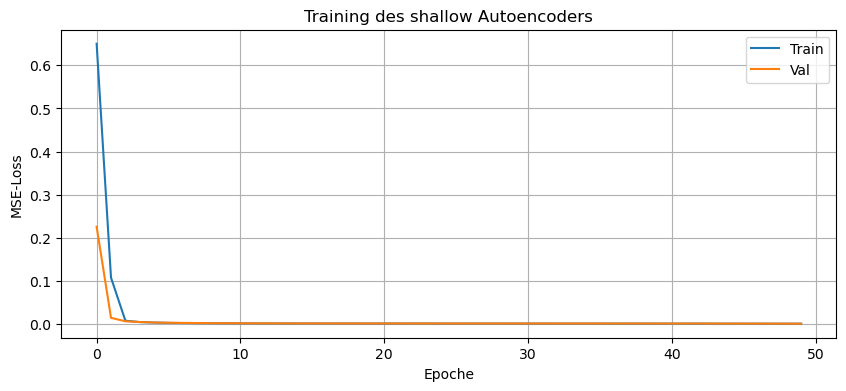

In [34]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(ae_history["train_loss"], label="Train")
ax.plot(ae_history["val_loss"], label="Val")
ax.set_title("Training des shallow Autoencoders")
ax.set_xlabel("Epoche")
ax.set_ylabel("MSE-Loss")
ax.legend()
plt.show()

## Block 9: Kontrollierter Simulations-Test mit injizierten Anomalien

Es wird ein bekanntes Stufenprofil aus dem Testsplit gewählt. In diesen Run werden drei typische Anomalietypen injiziert:

- Punktanomalie
- anhaltende Verschiebung
- Intervallanomalie mit Oszillation

In [36]:
def choose_demo_run(metadata_df: pd.DataFrame, family: Optional[str] = None, run_id: Optional[str] = None) -> str:
    test_meta = metadata_df[metadata_df["split"] == "test"].copy()

    if run_id is not None:
        return run_id

    if family is not None:
        test_meta = test_meta[test_meta["profile_family"] == family].copy()

    if len(test_meta) == 0:
        raise ValueError("Kein passender Demo-Run im Testsplit gefunden.")

    return test_meta["global_run_id"].iloc[0]


demo_global_run_id = choose_demo_run(
    metadata_df=metadata_df,
    family=CONFIG["demo_profile_family"],
    run_id=CONFIG["demo_run_id"],
)
demo_global_run_id

'v1__run_0002'

In [37]:
def inject_demo_anomalies(run_df: pd.DataFrame, config: Dict[str, Any]) -> Tuple[pd.DataFrame, List[Dict[str, Any]]]:
    df = run_df.sort_values("t_sec").reset_index(drop=True).copy()

    t = df["t_sec"].to_numpy(dtype=float)
    df["fault_active"] = 0
    df["fault_event_id"] = ""

    events = []

    start = config["demo_point_start_s"]
    end = start + config["demo_point_duration_s"]
    mask = (t >= start) & (t < end)
    df.loc[mask, "T1"] += config["demo_point_amplitude_degC"]
    df.loc[mask, "fault_active"] = 1
    df.loc[mask, "fault_event_id"] = "point_spike"
    events.append({"event_id": "point_spike", "start_s": start, "end_s": end})

    start = config["demo_shift_start_s"]
    end = config["demo_shift_end_s"]
    mask = (t >= start) & (t < end)
    df.loc[mask, "T2"] += config["demo_shift_amplitude_degC"]
    df.loc[mask, "fault_active"] = 1
    df.loc[mask, "fault_event_id"] = "mean_shift"
    events.append({"event_id": "mean_shift", "start_s": start, "end_s": end})

    start = config["demo_osc_start_s"]
    end = config["demo_osc_end_s"]
    mask = (t >= start) & (t < end)
    osc_t = t[mask] - start
    osc = config["demo_osc_amplitude_degC"] * np.sin(2 * np.pi * osc_t / config["demo_osc_period_s"])
    df.loc[mask, "T1"] += osc
    df.loc[mask, "T2"] -= 0.5 * osc
    df.loc[mask, "fault_active"] = 1
    df.loc[mask, "fault_event_id"] = "oscillation"
    events.append({"event_id": "oscillation", "start_s": start, "end_s": end})

    return df, events


demo_clean_df = timeseries_df[timeseries_df["global_run_id"] == demo_global_run_id].sort_values("t_sec").reset_index(drop=True)
demo_anom_df, demo_events = inject_demo_anomalies(demo_clean_df, CONFIG)

demo_events

[{'event_id': 'point_spike', 'start_s': 120, 'end_s': 125},
 {'event_id': 'mean_shift', 'start_s': 260, 'end_s': 360},
 {'event_id': 'oscillation', 'start_s': 430, 'end_s': 520}]

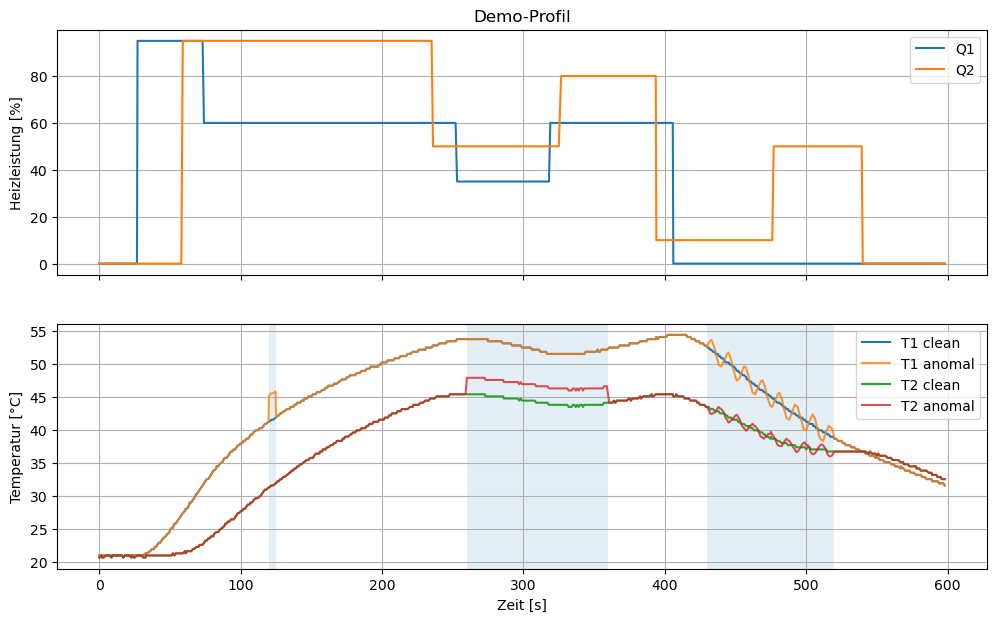

In [38]:
fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].plot(demo_clean_df["t_sec"], demo_clean_df["Q1"], label="Q1")
axes[0].plot(demo_clean_df["t_sec"], demo_clean_df["Q2"], label="Q2")
axes[0].set_ylabel("Heizleistung [%]")
axes[0].set_title("Demo-Profil")

axes[1].plot(demo_clean_df["t_sec"], demo_clean_df["T1"], label="T1 clean")
axes[1].plot(demo_clean_df["t_sec"], demo_anom_df["T1"], label="T1 anomal", alpha=0.8)
axes[1].plot(demo_clean_df["t_sec"], demo_clean_df["T2"], label="T2 clean")
axes[1].plot(demo_clean_df["t_sec"], demo_anom_df["T2"], label="T2 anomal", alpha=0.8)

for event in demo_events:
    axes[1].axvspan(event["start_s"], event["end_s"], alpha=0.12)

axes[1].set_xlabel("Zeit [s]")
axes[1].set_ylabel("Temperatur [°C]")

for ax in axes:
    ax.legend()

plt.show()

In [39]:
def build_windows_for_demo_run(
    run_df: pd.DataFrame,
    feature_cols: List[str],
    window_length_s: int,
    window_step_s: int,
    events: List[Dict[str, Any]],
) -> Tuple[np.ndarray, pd.DataFrame]:
    X_demo, meta_demo = build_windows_for_one_run(
        run_df=run_df,
        feature_cols=feature_cols,
        window_length_s=window_length_s,
        window_step_s=window_step_s,
    )

    event_ids = []
    fault_any = []

    for _, row in meta_demo.iterrows():
        win_start = row["window_start_s"]
        win_end = row["window_end_s"]

        overlapping = []
        for event in events:
            overlap = not (win_end < event["start_s"] or win_start > event["end_s"])
            if overlap:
                overlapping.append(event["event_id"])

        event_ids.append("|".join(overlapping))
        fault_any.append(int(len(overlapping) > 0))

    meta_demo = meta_demo.copy()
    meta_demo["fault_any"] = fault_any
    meta_demo["fault_event_ids"] = event_ids

    return X_demo, meta_demo


X_demo_raw, demo_window_meta = build_windows_for_demo_run(
    run_df=demo_anom_df,
    feature_cols=CONFIG["feature_cols"],
    window_length_s=CONFIG["window_length_s"],
    window_step_s=CONFIG["window_step_s"],
    events=demo_events,
)

X_demo_vec = transform_vector_windows(X_demo_raw, vector_scaler)

X_demo_raw.shape, demo_window_meta.shape

((293, 15, 2), (293, 12))

In [40]:
def get_model_scores_dict() -> Dict[str, Dict[str, Any]]:
    return {
        "PCA": {"threshold": pca_threshold},
        "IsolationForest": {"threshold": if_threshold},
        "OneClassSVM": {"threshold": ocsvm_threshold},
        "ShallowAE": {"threshold": ae_threshold},
    }


def score_demo_all_models() -> Dict[str, pd.DataFrame]:
    scores = {}

    pca_df = demo_window_meta.copy()
    pca_df["score"] = pca_anomaly_score(pca_model, X_demo_vec)
    scores["PCA"] = pca_df

    if_df = demo_window_meta.copy()
    if_df["score"] = if_anomaly_score(if_model, X_demo_vec)
    scores["IsolationForest"] = if_df

    ocsvm_df = demo_window_meta.copy()
    ocsvm_df["score"] = ocsvm_anomaly_score(ocsvm_model, X_demo_vec)
    scores["OneClassSVM"] = ocsvm_df

    ae_df = demo_window_meta.copy()
    ae_df["score"] = autoencoder_window_score(ae_model, X_demo_vec, device=device)
    scores["ShallowAE"] = ae_df

    return scores


thresholds = get_model_scores_dict()
demo_scores = score_demo_all_models()
demo_scores.keys()


dict_keys(['PCA', 'IsolationForest', 'OneClassSVM', 'ShallowAE'])

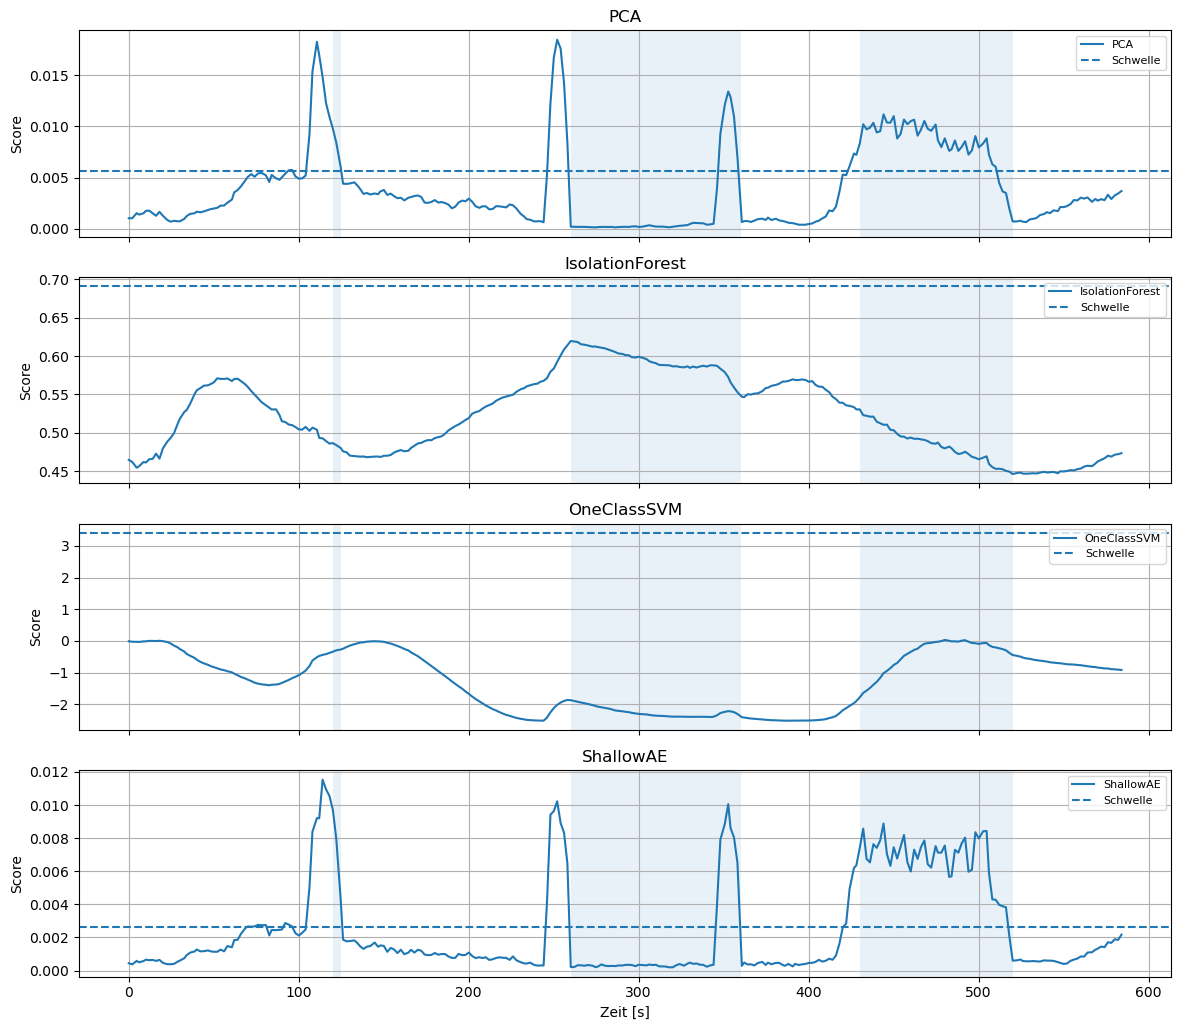

In [41]:
def plot_demo_scores(demo_scores: Dict[str, pd.DataFrame], thresholds: Dict[str, Dict[str, Any]]) -> None:
    n_models = len(demo_scores)
    fig, axes = plt.subplots(n_models, 1, figsize=(12, 2.6 * n_models), sharex=True)

    if n_models == 1:
        axes = [axes]

    for ax, (model_name, df) in zip(axes, demo_scores.items()):
        thr = thresholds[model_name]["threshold"]

        ax.plot(df["window_start_s"], df["score"], label=model_name)
        ax.axhline(thr, linestyle="--", label="Schwelle")

        for event in demo_events:
            ax.axvspan(event["start_s"], event["end_s"], alpha=0.10)

        ax.set_ylabel("Score")
        ax.set_title(model_name)
        ax.legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("Zeit [s]")
    plt.tight_layout()
    plt.show()


plot_demo_scores(demo_scores, thresholds)


## Block 10: Quantitative Auswertung

Die Auswertung umfasst:

- Schwellenwert bei festgelegter FAR
- False Alarm Rate
- grobe Alarme pro Stunde
- First Alarm Index
- Detection Delay
- Fault Detection Rate / Recall
- False Discovery Rate
- Persistenz
- Abklingzeit nach Fault-Ende


In [43]:
def collect_normal_test_scores() -> Dict[str, np.ndarray]:
    return {
        "PCA": pca_scores_test,
        "IsolationForest": if_scores_test,
        "OneClassSVM": ocsvm_scores_test,
        "ShallowAE": ae_scores_test,
    }


normal_test_scores = collect_normal_test_scores()
{k: v.shape for k, v in normal_test_scores.items()}
def merge_alarm_windows(window_starts: np.ndarray, preds: np.ndarray, step_s: int, merge_gap_windows: int) -> List[Tuple[float, float]]:
    alarm_idx = np.where(preds == 1)[0]
    if len(alarm_idx) == 0:
        return []

    events = []
    current_start = window_starts[alarm_idx[0]]
    current_end = current_start

    for prev_idx, idx in zip(alarm_idx[:-1], alarm_idx[1:]):
        if idx - prev_idx <= merge_gap_windows + 1:
            current_end = window_starts[idx]
        else:
            events.append((float(current_start), float(current_end)))
            current_start = window_starts[idx]
            current_end = current_start

    events.append((float(current_start), float(current_end)))
    return events


def event_level_metrics(
    score_df: pd.DataFrame,
    threshold: float,
    events: List[Dict[str, Any]],
    score_col: str,
    window_step_s: int,
    merge_gap_windows: int,
    persistency_horizon_windows: int,
) -> Dict[str, Any]:
    df = score_df.copy()
    df["alarm"] = (df[score_col] > threshold).astype(int)

    window_starts = df["window_start_s"].to_numpy(dtype=float)
    preds = df["alarm"].to_numpy(dtype=int)

    alarm_events = merge_alarm_windows(
        window_starts=window_starts,
        preds=preds,
        step_s=window_step_s,
        merge_gap_windows=merge_gap_windows,
    )

    per_event = []
    detected_events = 0

    for event in events:
        start_s = event["start_s"]
        end_s = event["end_s"]

        overlapping_alarm_idx = df.index[
            (df["alarm"] == 1) &
            (df["window_end_s"] >= start_s) &
            (df["window_start_s"] <= end_s)
        ].tolist()

        detected = len(overlapping_alarm_idx) > 0
        if detected:
            detected_events += 1
            first_idx = overlapping_alarm_idx[0]
            first_alarm_time = float(df.loc[first_idx, "window_start_s"])
            detection_delay_s = max(0.0, first_alarm_time - start_s)

            horizon_end_idx = min(first_idx + persistency_horizon_windows - 1, len(df) - 1)
            persistency = float(df.loc[first_idx:horizon_end_idx, "alarm"].mean())

            post_event_df = df[df["window_start_s"] > end_s].copy()
            post_alarm_idx = post_event_df.index[post_event_df["alarm"] == 1].tolist()
            if len(post_alarm_idx) > 0:
                last_post_fault_alarm_time = float(df.loc[post_alarm_idx[-1], "window_start_s"])
                clearance_time_s = max(0.0, last_post_fault_alarm_time - end_s)
            else:
                clearance_time_s = 0.0
        else:
            first_alarm_time = np.nan
            detection_delay_s = np.nan
            persistency = 0.0
            clearance_time_s = np.nan

        per_event.append({
            "event_id": event["event_id"],
            "detected": detected,
            "first_alarm_time_s": first_alarm_time,
            "detection_delay_s": detection_delay_s,
            "persistency_ratio": persistency,
            "clearance_time_s": clearance_time_s,
        })

    false_alarm_events = 0
    for alarm_start, alarm_end in alarm_events:
        overlap_any = False
        for event in events:
            if not (alarm_end < event["start_s"] or alarm_start > event["end_s"]):
                overlap_any = True
                break
        if not overlap_any:
            false_alarm_events += 1

    total_alarm_events = len(alarm_events)
    false_discovery_rate = (false_alarm_events / total_alarm_events) if total_alarm_events > 0 else 0.0
    fault_detection_rate = detected_events / len(events) if len(events) > 0 else np.nan
    first_alarm_index = int(np.where(preds == 1)[0][0]) if np.any(preds == 1) else -1

    return {
        "per_event": pd.DataFrame(per_event),
        "alarm_events": alarm_events,
        "first_alarm_index": first_alarm_index,
        "fault_detection_rate": float(fault_detection_rate),
        "false_discovery_rate": float(false_discovery_rate),
        "n_alarm_events": int(total_alarm_events),
        "n_false_alarm_events": int(false_alarm_events),
    }


def false_alarm_metrics_on_normal(scores: np.ndarray, threshold: float, window_step_s: int) -> Dict[str, float]:
    alarm = (scores > threshold).astype(int)
    far = float(alarm.mean())
    alarms_per_hour = float(far * (3600.0 / window_step_s))
    return {
        "far_window_level": far,
        "alarms_per_hour_approx": alarms_per_hour,
    }


In [44]:
evaluation_rows = []
per_event_results = {}

for model_name, df in demo_scores.items():
    threshold = thresholds[model_name]["threshold"]

    normal_metrics = false_alarm_metrics_on_normal(
        scores=normal_test_scores[model_name],
        threshold=threshold,
        window_step_s=CONFIG["window_step_s"],
    )

    event_metrics = event_level_metrics(
        score_df=df,
        threshold=threshold,
        events=demo_events,
        score_col="score",
        window_step_s=CONFIG["window_step_s"],
        merge_gap_windows=CONFIG["alarm_merge_gap_windows"],
        persistency_horizon_windows=CONFIG["persistency_horizon_windows"],
    )

    per_event_df_model = event_metrics["per_event"].copy()
    per_event_df_model["model"] = model_name
    per_event_results[model_name] = per_event_df_model

    mean_delay = float(per_event_df_model["detection_delay_s"].dropna().mean()) if per_event_df_model["detection_delay_s"].notna().any() else np.nan
    mean_persistency = float(per_event_df_model["persistency_ratio"].mean())
    mean_clearance = float(per_event_df_model["clearance_time_s"].dropna().mean()) if per_event_df_model["clearance_time_s"].notna().any() else np.nan

    evaluation_rows.append({
        "model": model_name,
        "threshold": threshold,
        "far_window_level": normal_metrics["far_window_level"],
        "alarms_per_hour_approx": normal_metrics["alarms_per_hour_approx"],
        "first_alarm_index": event_metrics["first_alarm_index"],
        "fault_detection_rate": event_metrics["fault_detection_rate"],
        "false_discovery_rate": event_metrics["false_discovery_rate"],
        "n_alarm_events": event_metrics["n_alarm_events"],
        "n_false_alarm_events": event_metrics["n_false_alarm_events"],
        "mean_detection_delay_s": mean_delay,
        "mean_persistency_ratio": mean_persistency,
        "mean_clearance_time_s": mean_clearance,
    })

evaluation_df = pd.DataFrame(evaluation_rows).sort_values("model").reset_index(drop=True)
per_event_df = pd.concat(per_event_results.values(), ignore_index=True)

display(evaluation_df)
display(per_event_df)


,model,threshold,far_window_level,alarms_per_hour_approx,first_alarm_index,fault_detection_rate,false_discovery_rate,n_alarm_events,n_false_alarm_events,mean_detection_delay_s,mean_persistency_ratio,mean_clearance_time_s
0,IsolationForest,0.690603,0.000000,0.000000,-1,0.0,0.0,0,0,NaN,0.0,NaN
1,OneClassSVM,3.407302,0.000000,0.000000,-1,0.0,0.0,0,0,NaN,0.0,NaN
2,PCA,0.005623,0.002562,4.611443,47,1.0,0.4,5,2,0.0,1.0,178.360000
3,ShallowAE,0.002627,0.022203,39.965841,35,1.0,0.5,6,3,0.0,1.0,182.373333


,event_id,detected,first_alarm_time_s,detection_delay_s,persistency_ratio,clearance_time_s,model
0,point_spike,True,106.31,0.0,1.0,385.04,PCA
1,mean_shift,True,248.07,0.0,1.0,150.04,PCA
2,oscillation,True,424.07,0.0,1.0,0.00,PCA
3,point_spike,False,NaN,NaN,0.0,NaN,IsolationForest
4,mean_shift,False,NaN,NaN,0.0,NaN,IsolationForest
5,oscillation,False,NaN,NaN,0.0,NaN,IsolationForest
6,point_spike,False,NaN,NaN,0.0,NaN,OneClassSVM
7,mean_shift,False,NaN,NaN,0.0,NaN,OneClassSVM
8,oscillation,False,NaN,NaN,0.0,NaN,OneClassSVM
9,point_spike,True,106.31,0.0,1.0,391.06,ShallowAE


## Alarmvisualisierung

Die folgenden Plots zeigen Score-Verläufe, Schwellen und alarmierte Fenster für den kontrollierten Simulations-Test.


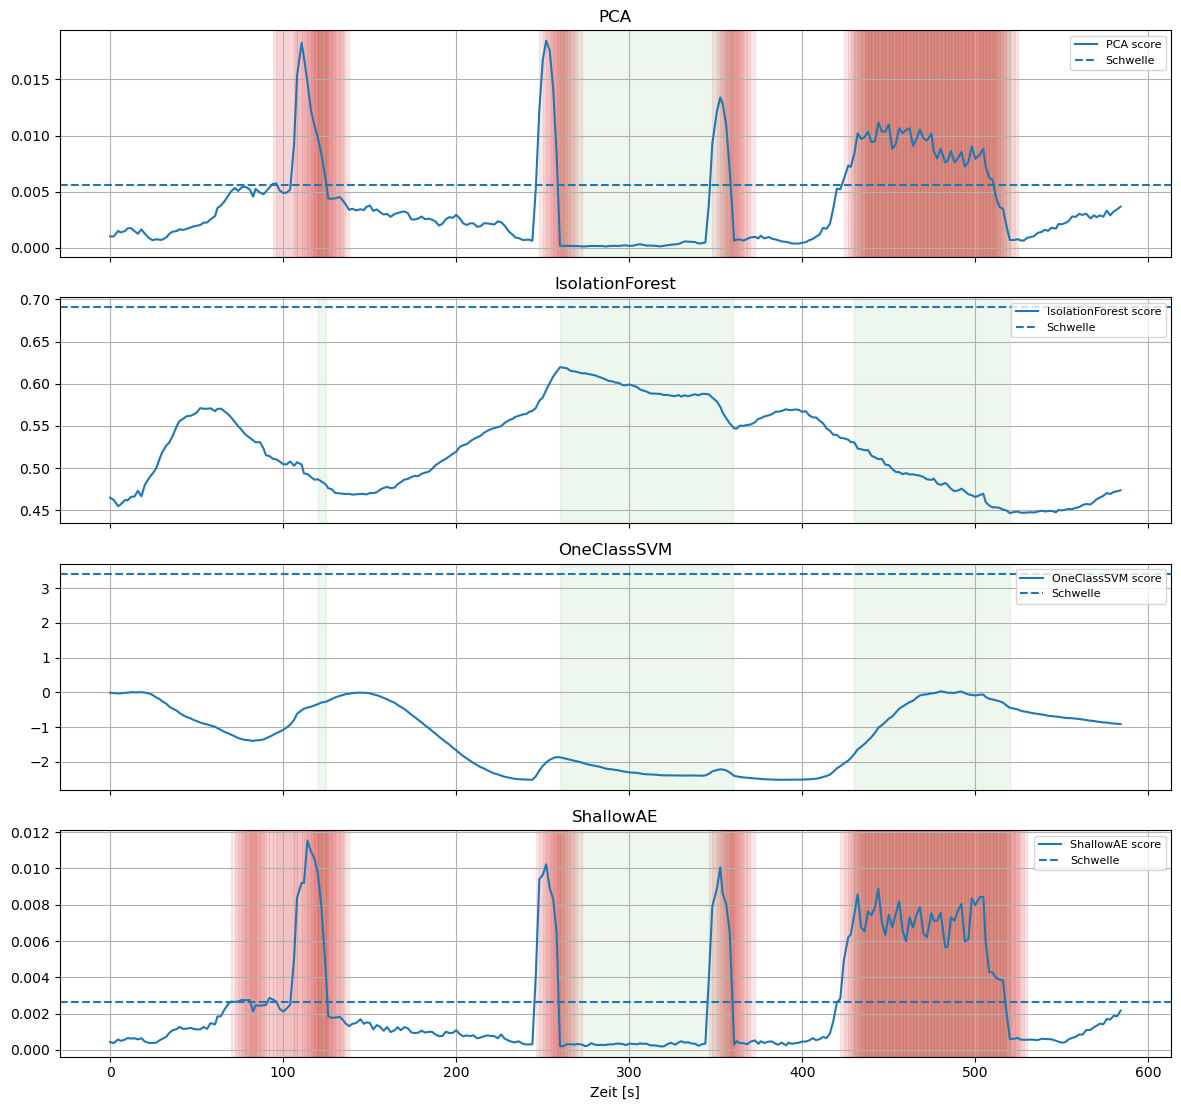

In [46]:
def plot_alarm_bands(
    demo_scores: Dict[str, pd.DataFrame],
    thresholds: Dict[str, Dict[str, Any]],
    events: List[Dict[str, Any]],
) -> None:
    n_models = len(demo_scores)
    fig, axes = plt.subplots(n_models, 1, figsize=(12, 2.8 * n_models), sharex=True)

    if n_models == 1:
        axes = [axes]

    for ax, (model_name, df) in zip(axes, demo_scores.items()):
        thr = thresholds[model_name]["threshold"]
        alarm = (df["score"] > thr).astype(int)

        ax.plot(df["window_start_s"], df["score"], label=f"{model_name} score")
        ax.axhline(thr, linestyle="--", label="Schwelle")

        for i, row in df.iterrows():
            if alarm.iloc[i] == 1:
                ax.axvspan(row["window_start_s"], row["window_end_s"], alpha=0.10, color="tab:red")

        for event in events:
            ax.axvspan(event["start_s"], event["end_s"], alpha=0.08, color="tab:green")

        ax.set_title(model_name)
        ax.legend(loc="upper right", fontsize=8)

    axes[-1].set_xlabel("Zeit [s]")
    plt.tight_layout()
    plt.show()


plot_alarm_bands(demo_scores, thresholds, demo_events)


## Block 11: Reflexion und Ausblick

Die Modelle wurden auf Simulations-Normaldaten trainiert und auf einem kontrollierten Simulations-Test verglichen.

Wichtige Beobachtungen:

- gute Offline-Ergebnisse auf Simulationsdaten sind ein erster Schritt
- Fensterung, Merkmalswahl und Schwellenwert haben starken Einfluss auf die Erkennung
- kurze Fehler werden bei großen Fenstern leichter verdünnt
- zusätzliche Merkmale oder andere Fensterparameter können das Verhalten der Modelle verändern

Das ist die Brücke zu weiteren Optimierungen und später zu Notebook 3.


## Eigene Notizen

- Welche Verfahren wirken stabil?
- Welche Verfahren reagieren früh, aber nervös?
- Wie plausibel sind Schwellen, FAR und Detection Delay?
- Soll die Merkmalswahl später auf Q1/Q2 oder Ableitungen erweitert werden?
- Welche Anpassungen sollen im nächsten Schritt getestet werden?
